<h1>Train — ResNet-18 (baseline)</h1>

Trains and evaluates the ResNet-18 baseline classifier, then saves its results (`results_resnet18.pkl`) and weights (`{COMPONENT}_resnet18_cnn.pt`) to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1945 | Val: 472 | Test: 90


## Define the model (Transfer Learning with ResNet-18)

In [2]:
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)  # no hidden layers — this one predates the tuning sweep

model_resnet18 = model_resnet18.to(device)

# ---------------------------------------------------------
# Loss and optimizer, with class weights for the imbalanced classes
# ---------------------------------------------------------
class_weights = make_class_weights(train_ds)
print("Applying class weights to loss function:")
for name, w in zip(class_names, class_weights.cpu().numpy()):
    print(f"  {name:<15s}: {w:.3f}")

criterion_resnet18 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet18 = optim.Adam(model_resnet18.parameters(), lr=5e-4, weight_decay=WEIGHT_DECAY)

# mode='min' because we want to minimize loss; factor=0.5 halves the LR when
# triggered; patience=3 waits 3 epochs with no improvement before reducing it
scheduler_resnet18 = ReduceLROnPlateau(optimizer_resnet18, mode='min', factor=0.5, patience=3)

Applying class weights to loss function:
  Dysfunctional  : 1.478
  Empty          : 1.667
  Functional     : 0.436
  Scum           : 0.420


## Train, then plot training curves

[ResNet-18] Epoch   1/100 | LR: 5.00e-04 | train loss 0.8859 acc 0.624 | val loss 0.9324 acc 0.648 *


[ResNet-18] Epoch   2/100 | LR: 5.00e-04 | train loss 0.5674 acc 0.745 | val loss 0.5639 acc 0.758 *


[ResNet-18] Epoch   3/100 | LR: 5.00e-04 | train loss 0.5510 acc 0.766 | val loss 0.5269 acc 0.752 *


[ResNet-18] Epoch   4/100 | LR: 5.00e-04 | train loss 0.4477 acc 0.811 | val loss 0.4740 acc 0.814 *


[ResNet-18] Epoch   5/100 | LR: 5.00e-04 | train loss 0.4452 acc 0.818 | val loss 0.4043 acc 0.845 *


...

[ResNet-18] Epoch  17/100 | LR: 1.25e-04 | train loss 0.0903 acc 0.961 | val loss 0.4123 acc 0.856


[ResNet-18] Epoch  18/100 | LR: 1.25e-04 | train loss 0.0797 acc 0.963 | val loss 0.3864 acc 0.864


[ResNet-18] Epoch  19/100 | LR: 6.25e-05 | train loss 0.0684 acc 0.970 | val loss 0.3862 acc 0.856


[ResNet-18] Epoch  20/100 | LR: 6.25e-05 | train loss 0.0540 acc 0.978 | val loss 0.3926 acc 0.856


[ResNet-18] Epoch  21/100 | LR: 6.25e-05 | train loss 0.0471 acc 0.978 | val loss 0.4069 acc 0.867

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 21.

[ResNet-18] Restored best checkpoint (val loss = 0.3414)


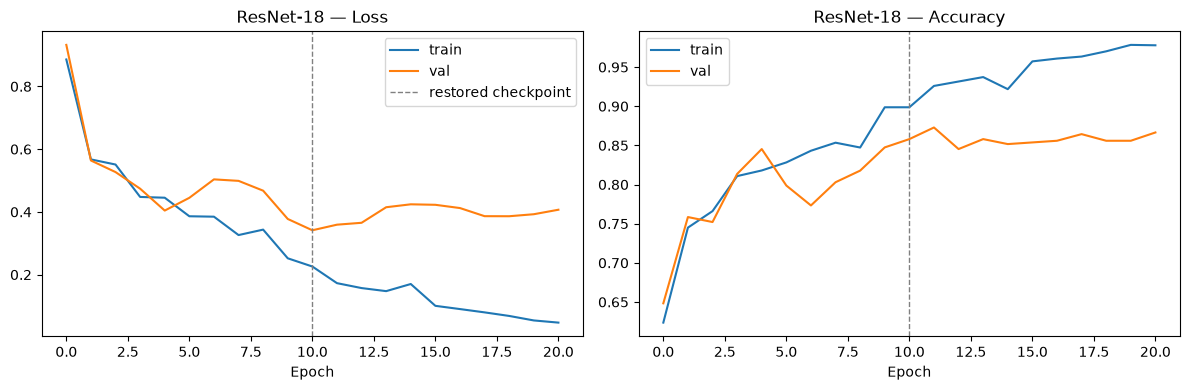

In [3]:
history_resnet18 = train_model(
    model_resnet18, train_loader, val_loader, optimizer_resnet18, scheduler_resnet18,
    criterion_resnet18, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18",
)
plot_training_curves(history_resnet18, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.822


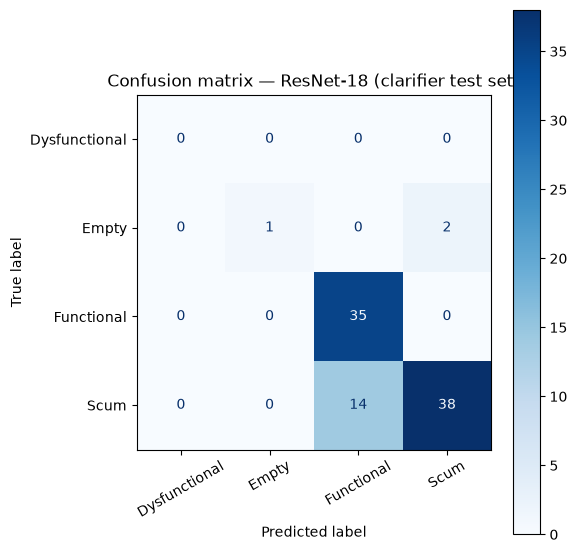

               precision    recall  f1-score   support

Dysfunctional      0.000     0.000     0.000         0
        Empty      1.000     0.333     0.500         3
   Functional      0.714     1.000     0.833        35
         Scum      0.950     0.731     0.826        52

     accuracy                          0.822        90
    macro avg      0.666     0.516     0.540        90
 weighted avg      0.860     0.822     0.818        90

  [warn] 'Dysfunctional' has 0 examples in this test set — AUC undefined, skipping.


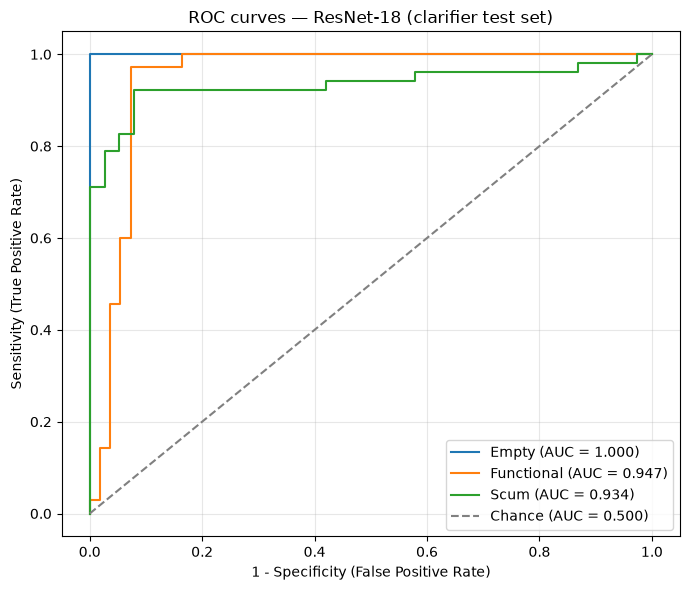

AUC (area under ROC curve) per class:
  Dysfunctional  : undefined (0 examples)
  Empty          : 1.000
  Functional     : 0.947
  Scum           : 0.934

Mean AUC (over 3/4 classes with test examples): 0.960


(np.float64(0.8222222222222222),
 {'Dysfunctional': nan,
  'Empty': 1.0,
  'Functional': 0.9470129870129871,
  'Scum': 0.9337044534412956})

In [4]:
evaluate_and_record(
    model_resnet18, test_loader, "ResNet-18", history_resnet18,
    img_size=IMG_TARGET_SIZE, hidden_layers=0, neurons=None,
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [5]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_clarifier_resnet18_Atlantis.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
